[*********************100%***********************]  1 of 1 completed


(4084, 5)
2.220446049250313e-16


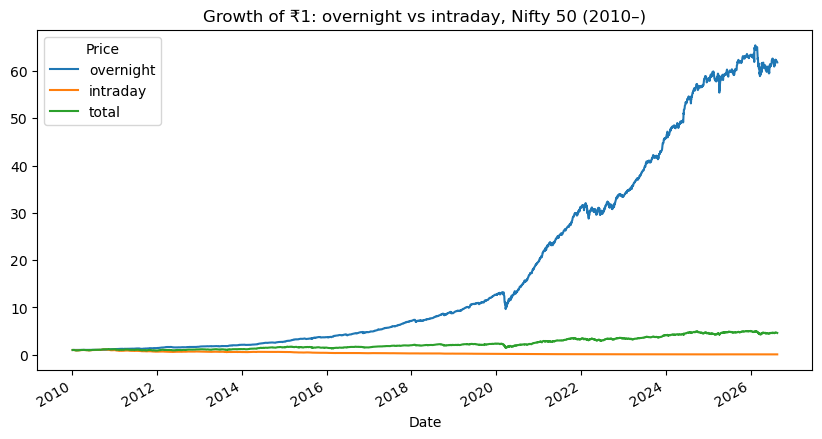

Price
overnight    61.79
intraday      0.07
total         4.60
Name: 2026-08-19 00:00:00, dtype: float64


In [1]:
import yfinance as yf
import pandas as pd

df = yf.download("^NSEI", start="2010-01-01")
print(df.shape)
df.head()
df.columns = df.columns.droplevel(1)


df["overnight"] = df["Open"] / df["Close"].shift(1) - 1
df["intraday"] = df["Close"] / df["Open"] - 1
df["total"] = df["Close"] / df["Close"].shift(1) - 1

# sanity check — should be ~1e-15
check = (1 + df["overnight"]) * (1 + df["intraday"]) - 1
print((check - df["total"]).abs().max())

import matplotlib.pyplot as plt
(1 + df[["overnight", "intraday", "total"]].fillna(0)).cumprod().plot(figsize=(10, 5))
plt.title("Growth of ₹1: overnight vs intraday, Nifty 50 (2010–)")
plt.show()

final = (1 + df[["overnight","intraday","total"]].fillna(0)).cumprod().iloc[-1]
print(final.round(2))

In [2]:
stale = (df["Open"] == df["Close"].shift(1))
print("Exactly stale opens:", stale.sum(), "out of", len(df))

# also catch near-stale: open within 0.01% of previous close
near_stale = (df["overnight"].abs() < 0.0001)
print("Near-zero overnight moves:", near_stale.sum())

Exactly stale opens: 12 out of 4084
Near-zero overnight moves: 161


In [3]:
print("10 biggest overnight gains:")
print(df["overnight"].nlargest(10))
print("\n10 biggest overnight losses:")
print(df["overnight"].nsmallest(10))

10 biggest overnight gains:
Date
2026-02-03    0.048614
2020-04-07    0.044843
2020-05-13    0.042152
2020-04-17    0.036768
2024-06-03    0.035827
2020-03-27    0.035602
2026-04-08    0.031634
2020-03-24    0.031280
2020-03-31    0.029978
2011-10-28    0.028951
Name: overnight, dtype: float64

10 biggest overnight losses:
Date
2020-03-23   -0.091448
2016-11-09   -0.055720
2020-03-13   -0.050317
2025-04-07   -0.050036
2020-03-19   -0.047882
2020-03-12   -0.040011
2020-03-16   -0.036905
2020-06-12   -0.036058
2018-02-06   -0.034819
2011-08-09   -0.033330
Name: overnight, dtype: float64


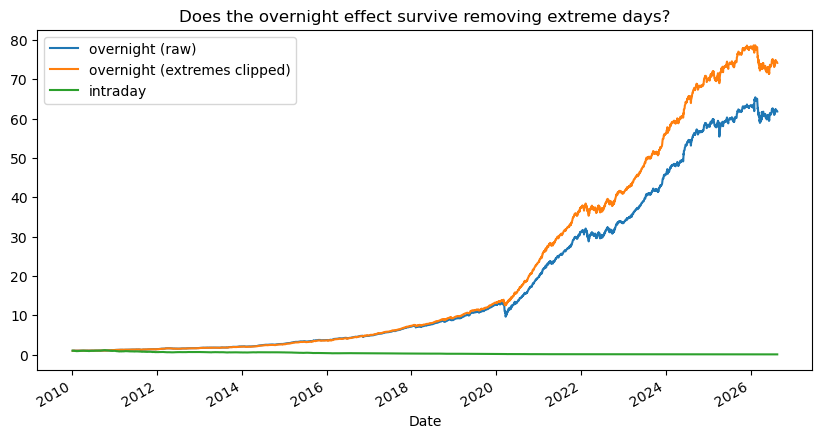

In [4]:
lo, hi = df["overnight"].quantile([0.01, 0.99])
trimmed = df["overnight"].clip(lo, hi)

import matplotlib.pyplot as plt
ax = (1 + df["overnight"].fillna(0)).cumprod().plot(label="overnight (raw)", figsize=(10,5))
(1 + trimmed.fillna(0)).cumprod().plot(ax=ax, label="overnight (extremes clipped)")
(1 + df["intraday"].fillna(0)).cumprod().plot(ax=ax, label="intraday")
ax.legend()
ax.set_title("Does the overnight effect survive removing extreme days?")
plt.show()

In [5]:
import numpy as np

stats = pd.DataFrame({
    "mean (bps/day)": df[["overnight","intraday","total"]].mean() * 1e4,
    "vol (bps/day)": df[["overnight","intraday","total"]].std() * 1e4,
    "ann. return %": df[["overnight","intraday","total"]].mean() * 252 * 100,
    "ann. vol %": df[["overnight","intraday","total"]].std() * np.sqrt(252) * 100,
})
rf = 0.065  # India ~6.5% annual; state the assumption
stats["Sharpe"] = (stats["ann. return %"] - rf*100) / stats["ann. vol %"]
print(stats.round(2))

# t-test: is the overnight mean statistically distinguishable from zero?
from scipy import stats as sps
t, p = sps.ttest_1samp(df["overnight"].dropna(), 0)
print(f"\nOvernight vs 0: t = {t:.2f}, p = {p:.4f}")
t2, p2 = sps.ttest_1samp(df["intraday"].dropna(), 0)
print(f"Intraday vs 0:  t = {t2:.2f}, p = {p2:.4f}")

           mean (bps/day)  vol (bps/day)  ann. return %  ann. vol %  Sharpe
Price                                                                      
overnight           10.29          60.78          25.93        9.65    2.01
intraday            -5.97          86.75         -15.04       13.77   -1.56
total                4.28         103.74          10.79       16.47    0.26

Overnight vs 0: t = 10.82, p = 0.0000
Intraday vs 0:  t = -4.40, p = 0.0000


In [6]:
periods = {
    "2010–2015": ("2010-01-01", "2015-12-31"),
    "2016–2020": ("2016-01-01", "2020-12-31"),
    "2021–2026": ("2021-01-01", "2026-12-31"),
}

rows = []
for label, (start, end) in periods.items():
    sub = df.loc[start:end]
    rows.append({
        "period": label,
        "overnight ann. %": sub["overnight"].mean() * 252 * 100,
        "intraday ann. %": sub["intraday"].mean() * 252 * 100,
        "n days": len(sub),
    })
print(pd.DataFrame(rows).round(1).to_string(index=False))

   period  overnight ann. %  intraday ann. %  n days
2010–2015              23.0            -14.2    1465
2016–2020              34.9            -21.5    1228
2021–2026              21.1            -10.2    1391


In [7]:
df["roll_vol"] = df["total"].rolling(21).std()
threshold = df["roll_vol"].quantile(0.75)
df["regime"] = np.where(df["roll_vol"] > threshold, "high vol", "calm")

regime_stats = df.groupby("regime")[["overnight", "intraday"]].mean() * 252 * 100
regime_stats["n days"] = df.groupby("regime").size()
print(regime_stats.round(1))

Price     overnight  intraday  n days
regime                               
calm           23.3     -14.6    3068
high vol       33.9     -16.2    1016


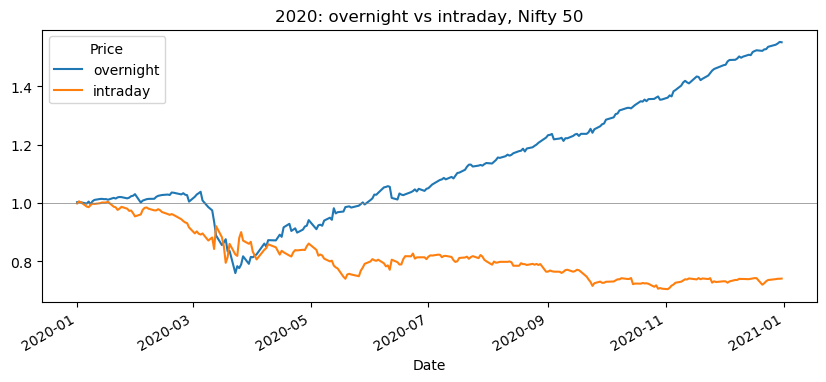

In [8]:
sub = df.loc["2020-01-01":"2020-12-31"]
(1 + sub[["overnight", "intraday"]].fillna(0)).cumprod().plot(figsize=(10, 4))
plt.title("2020: overnight vs intraday, Nifty 50")
plt.axhline(1, color="grey", lw=0.5)
plt.show()

## Transaction costs: could anyone trade this?

No, a mixture of spread, transaction fees, and slippage make these trades unprofitable.

In [9]:
edge_bps = 10.3        # average overnight return, from your stats table
cost_bps = 5.9         # your researched all-in round-trip cost — fill in

for c in [2, 4, 6, 8, 10]:
    net = edge_bps - c
    print(f"cost {c:>2} bps → net {net:>5.1f} bps/night → {net*252/100:>6.1f}% annualised")

cost  2 bps → net   8.3 bps/night →   20.9% annualised
cost  4 bps → net   6.3 bps/night →   15.9% annualised
cost  6 bps → net   4.3 bps/night →   10.8% annualised
cost  8 bps → net   2.3 bps/night →    5.8% annualised
cost 10 bps → net   0.3 bps/night →    0.8% annualised



The overnight trade earns 10.3 bps per night, or roughly 26% annualised gross.
A round trip costs about 5.9 bps, based on Zerodha's brokerage calculator for
one Nifty futures lot — most of it STT. That leaves a net edge of 4.4 bps per
night, or about 11% annualised, which would be further reduced by slippage and
the bid-ask spread. At 11%, the strategy sits only ~4.5% above India's
risk-free rate. It is worth questioning whether that extra 4.5% warrants the
risk of holding overnight through crashes like Covid-19. So why doesn't everyone trade overnight and earn 26%?
From that 4.5%, an unknown amount is subtracted due to slippage and spread, and the rest can be thought of as compensation for the risk taken by holding it through potential overnight crashes.
